### Import

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [70]:
df = pd.read_csv("../data/processed/online_retail.csv")

In [71]:
X = df.drop(columns=['InvoiceDate', 'Invoice', 'StockCode', 'Customer ID'])

In [72]:
customer_features = df.copy()

In [73]:
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=78)
X_pca = pca.fit_transform(X_scaled)

Using PCA to reduce dimensionality so clusters can be visualized.

Also i chose it instead of UMAP or T-SNE, because there're 780k of rows and PCA is the fastest version of dimension reduction.

---

### K-Means analysis

In [74]:
kmeans = KMeans(
    n_clusters=3,
    random_state=78
)

In [75]:
labels = kmeans.fit_predict(X_scaled)

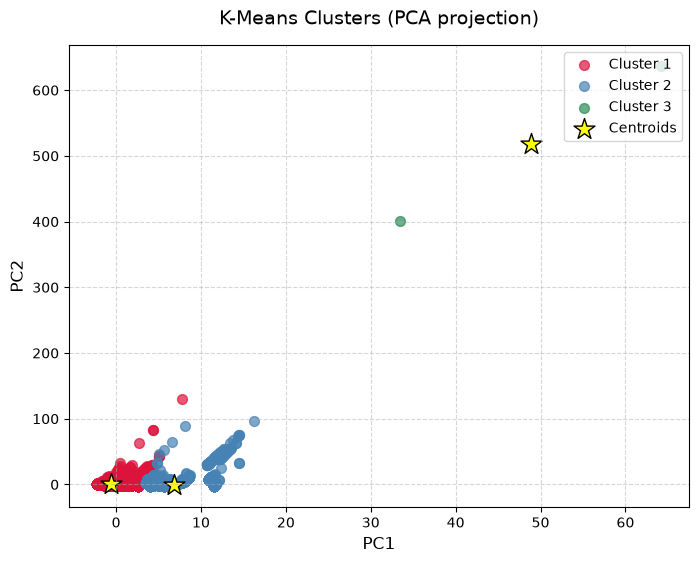

In [76]:
plt.figure(figsize=(8, 6))

colors = ["crimson", "steelblue", "seagreen"]

for cluster_id, color in enumerate(colors):
    mask = labels == cluster_id
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=50,
        c=color,
        alpha=0.7,
        label=f"Cluster {cluster_id + 1}",
    )

centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=250,
    c="yellow",
    marker="*",
    edgecolors="black",
    linewidths=1.0,
    label="Centroids",
)

plt.title("K-Means Clusters (PCA projection)", fontsize=14, pad=15)
plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.legend(loc="upper right", frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

---

### Inspecting clusters and outliers in it 

Before removing the "outlier" cluster, let's check:
- how many rows/customers, and whether the extreme values are real

In [82]:
cluster_summary = (
    df.assign(cluster=labels)
    .groupby("cluster")
    .agg(
        n_rows=("Invoice", "count"),
        n_customers=("Customer ID", "nunique"),
        avg_quantity=("Quantity", "mean"),
        avg_total_revenue=("total_revenue", "mean"),
        avg_num_orders=("num_orders", "mean"),
        avg_recency_days=("recency_days", "mean"),
        avg_cancelled_orders=("sum_cancelled_orders", "mean"),
    )
    .round(2)
)

cluster_summary

,n_rows,n_customers,avg_quantity,avg_total_revenue,avg_num_orders,avg_recency_days,avg_cancelled_orders
cluster,,,,,,,
0,718699,5861,11.65,7909.17,16.73,88.27,3.93
1,60722,23,32.72,173242.36,230.70,2.83,58.75
2,2,2,77605.00,123014.48,7.00,162.50,3.50


In the second cluster i found out that there's only two customers which buying products pretty rarely but with high quantity and because of it revenue.

I'll drop them because they distort my plot so i can't analyze properly other type of clusters.

---

### Dropping the outlier cluster

PCA doesn't reorder rows — `X_pca[i]` still corresponds to `df.iloc[i]`

So I can drop the outlier customers by filtering on the cluster labels, not on the PCA coordinates

In [85]:
outlier_cluster = 2

keep_mask = labels != outlier_cluster

df_clean = df[keep_mask].reset_index(drop=True)
X_clean = X[keep_mask].reset_index(drop=True)

X_scaled_clean = X_scaled[keep_mask]
X_pca_clean = X_pca[keep_mask]

print(f"Rows before: {len(df)} -> after: {len(df_clean)}")

Rows before: 779423 -> after: 779421


In [86]:
kmeans_clean = KMeans(n_clusters=3, random_state=78)
labels_clean = kmeans_clean.fit_predict(X_scaled_clean)

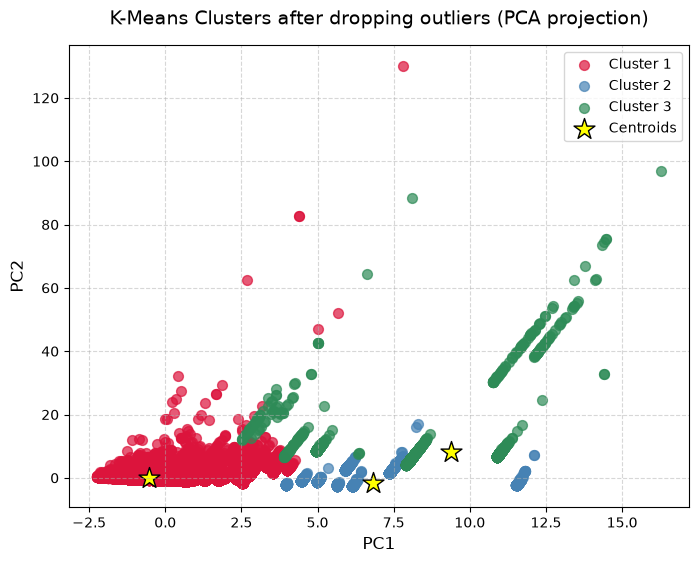

In [87]:
plt.figure(figsize=(8, 6))

colors = ["crimson", "steelblue", "seagreen"]

for cluster_id, color in enumerate(colors):
    mask = labels_clean == cluster_id
    plt.scatter(
        X_pca_clean[mask, 0],
        X_pca_clean[mask, 1],
        s=50,
        c=color,
        alpha=0.7,
        label=f"Cluster {cluster_id + 1}",
    )

centroids_pca = pca.transform(kmeans_clean.cluster_centers_)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=250,
    c="yellow",
    marker="*",
    edgecolors="black",
    linewidths=1.0,
    label="Centroids",
)

plt.title("K-Means Clusters after dropping outliers (PCA projection)", fontsize=14, pad=15)
plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.legend(loc="upper right", frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

---